## 1) Install + imports (Kaggle cell)

In [2]:
!pip install -U open_clip_torch==2.23.0 
# !pip install transformers==4.35.2 
!pip install pillow tqdm pandas

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.5/1.5 MB 65.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 44.8/44.8 kB 3.3 MB/s eta 0:00:00


## 2) Load BiomedCLIP (Kaggle cell)

In [3]:
import os
from pathlib import Path
import pandas as pd
from PIL import Image
from tqdm.auto import tqdm

import torch
from open_clip import create_model_from_pretrained, get_tokenizer

MODEL_ID = "hf-hub:microsoft/BiomedCLIP-PubMedBERT_256-vit_base_patch16_224"
CONTEXT_LEN = 256  # model README uses 256 :contentReference[oaicite:2]{index=2}

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# Load model + preprocess + tokenizer (as in model README)
model, preprocess = create_model_from_pretrained(MODEL_ID)   # :contentReference[oaicite:3]{index=3}
tokenizer = get_tokenizer(MODEL_ID)                          # :contentReference[oaicite:4]{index=4}

model = model.to(device)
model.eval()

print("Device:", device)

/usr/local/lib/python3.12/dist-packages/pydantic/_internal/_generate_schema.py:2249: UnsupportedFieldAttributeWarning: The 'repr' attribute with value False was provided to the `Field()` function, which has no effect in the context it was used. 'repr' is field-specific metadata, and can only be attached to a model field using `Annotated` metadata or by assignment. This may have happened because an `Annotated` type alias using the `type` statement was used, or if the `Field()` function was attached to a single member of a union type.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/pydantic/_internal/_generate_schema.py:2249: UnsupportedFieldAttributeWarning: The 'frozen' attribute with value True was provided to the `Field()` function, which has no effect in the context it was used. 'frozen' is field-specific metadata, and can only be attached to a model field using `Annotated` metadata or by assignment. This may have happened because an `Annotated` type alias using the `type` 

open_clip_pytorch_model.bin:   0%|          | 0.00/784M [00:00<?, ?B/s]

open_clip_config.json:   0%|          | 0.00/707 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/385 [00:00<?, ?B/s]

2026-01-01 19:36:19.922717: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:467] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1767296180.125070      55 cuda_dnn.cc:8579] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1767296180.186485      55 cuda_blas.cc:1407] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
W0000 00:00:1767296180.629486      55 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1767296180.629532      55 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1767296180.629535      55 computation_placer.cc:177] computation placer alr

tokenizer_config.json:   0%|          | 0.00/28.0 [00:00<?, ?B/s]

vocab.txt: 0.00B [00:00, ?B/s]

Device: cuda


## 3) Prompts + text-embedding “prompt ensembling” (Kaggle cell)

This makes the model more stable by using multiple prompts per class and averaging them.

In [22]:
# ---------------------------
# Prompt pack tuned for paper panel crops (BiomedCLIP)
# ---------------------------

TEMPLATES = [
    "a photo of {}",
    "an image of {}",
    "a cropped scientific figure panel of {}",
    "a research paper figure panel showing {}",
    "a biomedical figure panel showing {}",
    "this figure panel shows {}",
    "a low-resolution paper panel showing {}",
    "a published figure panel containing {}",
]

# Stage A: imaging vs non-imaging
GROUP_PROMPTS = {
    "imaging": [
        # microscopy / micrographs
        "a microscopy image",
        "a micrograph of cells",
        "a fluorescence microscopy image",
        "a confocal microscopy image",
        "a brightfield microscopy image",
        "a phase contrast microscopy image",
        "an electron microscopy image",
        "a micrograph with a scale bar",
        "a merged multi-channel microscopy image",

        # histology/pathology slides
        "a histology tissue section image",
        "an H&E stained tissue section",
        "an immunohistochemistry (IHC) stained tissue image",
        "a pathology slide image",
        "a digital pathology whole slide image tile",

        # gels / blots
        "a western blot image",
        "a gel electrophoresis image",
        "an SDS-PAGE gel image",
        "a blot with lanes and bands",

        # radiology / scans
        "a chest x-ray image",
        "a CT scan image",
        "an MRI scan image",
        "an ultrasound image",
        "a PET scan image",

        # clinical photos / procedures
        "a clinical photograph",
        "a gross pathology specimen photo",
        "a dermatology clinical photo",
        "an endoscopy image",

        # ophthalmology
        "a fundus retina photograph",
        "an OCT retinal scan image",

        # plates/assays
        "a petri dish photo",
        "a colony assay plate image",
        "a multi-well plate photo",
    ],

    "non_imaging": [
        # plots/charts
        "a bar chart",
        "a line chart",
        "a scatter plot",
        "a box plot",
        "a violin plot",
        "a dot plot",
        "a volcano plot",
        "a ROC curve",
        "a Kaplan-Meier survival curve",
        "a PCA plot",
        "a UMAP plot",
        "a t-SNE plot",

        # tables/heatmaps
        "a table of numbers",
        "a heatmap plot",
        "a matrix heatmap with labels",

        # flow cytometry (usually treated as non-imaging)
        "a flow cytometry dot plot",
        "a flow cytometry histogram",
        "a FACS gating plot",

        # schematics/diagrams
        "a schematic diagram",
        "a pathway diagram",
        "a biological network diagram",
        "a flowchart",
        "a cartoon illustration",

        # molecular renderings / structures (non-imaging)
        "a protein ribbon diagram",
        "a molecular structure rendering",
        "a chemical structure diagram",

        # genomics/bioinfo visuals
        "a genome browser track plot",
        "a phylogenetic tree diagram",
        "a sequence alignment figure",

        # text panels / UI
        "a text-only panel",
        "a panel of labels and annotations",
        "a screenshot of software output",
    ],
}

# Stage B: imaging subtype (only if group_pred == imaging)
SUBTYPE_PROMPTS = {
    "blot_gel": [
        "a western blot membrane with lanes and bands",
        "a blot panel with protein bands",
        "a gel electrophoresis image with lanes",
        "an SDS-PAGE gel with a ladder",
        "a grayscale gel or blot panel",
        "a blot panel showing band intensity differences",
    ],

    "microscopy": [
        "a microscopy image of cells with a scale bar",
        "a fluorescence microscopy image with colored channels",
        "a confocal microscopy micrograph",
        "a brightfield microscopy micrograph",
        "a phase contrast microscopy image",
        "a merged multi-channel microscopy image",
        "an electron microscopy micrograph (TEM or SEM)",
        "a microscopy image showing nuclei stained with DAPI",
    ],

    "histology_pathology": [
        "an H&E stained histology tissue section",
        "a histopathology slide image of tissue",
        "an immunohistochemistry (IHC) stained tissue section",
        "a pathology biopsy slide image",
        "a digital pathology whole-slide scan tile",
        "a tissue section showing glands and stroma",
    ],

    "radiology": [
        "a chest x-ray radiograph",
        "a CT scan slice",
        "an MRI scan slice",
        "an ultrasound scan image",
        "a PET scan image",
        "a radiology medical imaging scan with grayscale anatomy",
    ],

    "clinical_photo": [
        "a clinical photograph of a patient condition",
        "a dermatology clinical photo of skin",
        "a gross pathology specimen photograph",
        "a surgical specimen photo",
        "a medical photograph taken with a camera",
    ],

    "ophthalmology": [
        "a fundus retina photograph",
        "an OCT retinal scan",
        "a fluorescein angiography retina image",
        "an ophthalmology clinical image of the eye",
    ],

    "endoscopy": [
        "an endoscopy image from inside the body",
        "a colonoscopy frame",
        "a bronchoscopy frame",
        "a laparoscopy image",
        "an internal organ endoscopic view",
    ],

    "assay_plate": [
        "a petri dish colony assay photo",
        "a bacterial colony plate image",
        "a spot assay plate image",
        "a multi-well plate photo",
        "an agar plate experiment photo",
    ],

    "other_imaging": [
        "a biomedical photograph that is not microscopy or radiology",
        "a device-captured biomedical image of unknown type",
        "a hard-to-categorize imaging panel",
        "a mixed imaging panel",
    ],
}



@torch.no_grad()
def build_class_text_features(class_to_prompts: dict) -> tuple[list[str], torch.Tensor]:
    """
    Returns:
      labels: list of class names
      feats:  [num_classes, dim] normalized
    """
    labels = []
    class_feats = []

    for cls, prompts in class_to_prompts.items():
        all_texts = []
        for p in prompts:
            for tmpl in TEMPLATES:
                all_texts.append(tmpl.format(p))

        tokens = tokenizer(all_texts, context_length=CONTEXT_LEN).to(device)

        # open_clip models expose encode_text
        text_features = model.encode_text(tokens)
        text_features = text_features / text_features.norm(dim=-1, keepdim=True)

        # mean pool across prompts -> one embedding per class
        cls_feat = text_features.mean(dim=0)
        cls_feat = cls_feat / cls_feat.norm()

        labels.append(cls)
        class_feats.append(cls_feat)

    feats = torch.stack(class_feats, dim=0)  # [C, D]
    return labels, feats

group_labels, group_text_feats = build_class_text_features(GROUP_PROMPTS)
sub_labels,   sub_text_feats   = build_class_text_features(SUBTYPE_PROMPTS)

print("Group labels:", group_labels)
print("Subtype labels:", sub_labels)

Group labels: ['imaging', 'non_imaging']
Subtype labels: ['blot_gel', 'microscopy', 'histology_pathology', 'radiology', 'clinical_photo', 'ophthalmology', 'endoscopy', 'assay_plate', 'other_imaging']


## 4) Iterate directory → batch images → predict → save CSV (Kaggle cell)

In [23]:
def list_images(root: Path):
    return [p for p in root.rglob("*") if p.suffix.lower() in IMAGE_EXTS]

@torch.no_grad()
def predict_batch(image_paths, group_labels, group_text_feats, sub_labels, sub_text_feats):
    # Load + preprocess
    imgs = []
    valid_paths = []
    for p in image_paths:
        try:
            im = Image.open(p).convert("RGB")
            imgs.append(preprocess(im))
            valid_paths.append(p)
        except Exception:
            # skip unreadable files
            continue

    if not imgs:
        return []

    images = torch.stack(imgs, dim=0).to(device)

    # Encode images
    image_features = model.encode_image(images)
    image_features = image_features / image_features.norm(dim=-1, keepdim=True)

    # Similarities (logit_scale is standard CLIP)
    logit_scale = model.logit_scale.exp()

    # Step-1: imaging vs non-imaging
    group_logits = logit_scale * (image_features @ group_text_feats.T)   # [B, 2]
    group_probs = group_logits.softmax(dim=-1)

    # Step-2: subtype (computed for all, but used only when imaging)
    sub_logits = logit_scale * (image_features @ sub_text_feats.T)       # [B, K]
    sub_probs = sub_logits.softmax(dim=-1)

    results = []
    for i, p in enumerate(valid_paths):
        g_idx = int(group_probs[i].argmax().item())
        group_pred = group_labels[g_idx]
        group_conf = float(group_probs[i, g_idx].item())

        # If predicted imaging, pick subtype; else set subtype="non_imaging"
        if group_pred == "imaging":
            s_idx = int(sub_probs[i].argmax().item())
            subtype_pred = sub_labels[s_idx]
            subtype_conf = float(sub_probs[i, s_idx].item())
        else:
            subtype_pred = "non_imaging"
            subtype_conf = 1.0 - group_conf  # rough indicator

        row = {
            "path": str(p),
            "filename": p.name,
            "group_pred": group_pred,
            "group_conf": group_conf,
            "subtype_pred": subtype_pred,
            "subtype_conf": subtype_conf,
        }

        # optional: keep per-class probabilities (helpful for debugging)
        for j, lab in enumerate(group_labels):
            row[f"p_group_{lab}"] = float(group_probs[i, j].item())
        for j, lab in enumerate(sub_labels):
            row[f"p_sub_{lab}"] = float(sub_probs[i, j].item())

        results.append(row)

    return results

In [32]:
# ---- Set your input directory here ----
# ROOT_DIR = Path("/kaggle/input/panel-det-yolov5-results/runs/kept/crops/blots/batch_000")
ROOT_DIR = Path("/kaggle/input/panel-det-yolov5-results/runs/kept/crops/")

OUT_CSV = Path("/kaggle/working/biomedclip_panel_predictions.csv")

IMAGE_EXTS = {".jpg", ".jpeg", ".png", ".bmp", ".tif", ".tiff", ".webp"}

In [33]:
# --- Run ---
all_imgs = list_images(ROOT_DIR)
print("Found images:", len(all_imgs))

BATCH_SIZE = 16 # 64  # adjust based on GPU RAM

rows = []
for i in tqdm(range(0, len(all_imgs), BATCH_SIZE), desc="Predicting"):
    batch_paths = all_imgs[i:i+BATCH_SIZE]
    rows.extend(predict_batch(batch_paths, group_labels, group_text_feats, sub_labels, sub_text_feats))

Found images: 50437


Predicting:   0%|          | 0/3153 [00:00<?, ?it/s]

In [30]:
df = pd.DataFrame(rows)
df.to_csv(OUT_CSV, index=False)
print("Saved:", OUT_CSV)

df.head(100)

Saved: /kaggle/working/biomedclip_panel_predictions.csv


,path,filename,group_pred,group_conf,subtype_pred,subtype_conf,p_group_imaging,p_group_non_imaging,p_sub_blot_gel,p_sub_microscopy,p_sub_histology_pathology,p_sub_radiology,p_sub_clinical_photo,p_sub_ophthalmology,p_sub_endoscopy,p_sub_assay_plate,p_sub_other_imaging
0,/kaggle/input/panel-det-yolov5-results/runs/ke...,000069__MBO3-14-e70150-g006__c9e42595__d001.png,imaging,0.985142,blot_gel,0.999734,0.985142,0.014858,0.999734,4.990023e-06,1.408258e-07,1.139575e-06,8.143482e-08,6.268525e-08,2.984103e-10,2.597190e-04,2.661306e-07
1,/kaggle/input/panel-det-yolov5-results/runs/ke...,000033__TACS_A_2598971_F0005_PC__ad5bad78__d00...,imaging,0.914443,blot_gel,0.999557,0.914443,0.085557,0.999557,2.977374e-06,3.797433e-07,4.284937e-04,4.923398e-08,5.572161e-10,2.548300e-10,5.132709e-06,6.143270e-06
2,/kaggle/input/panel-det-yolov5-results/runs/ke...,000012__MBO3-14-e70150-g005__b1df6693__d000.png,imaging,0.893458,blot_gel,0.998100,0.893458,0.106542,0.998100,1.020397e-03,3.132186e-04,5.544793e-05,3.968132e-04,1.509464e-07,7.137610e-07,9.629945e-05,1.689408e-05
3,/kaggle/input/panel-det-yolov5-results/runs/ke...,000052__TACS_A_2598971_F0005_PC__ad5bad78__d00...,non_imaging,0.756822,non_imaging,0.243178,0.243178,0.756822,0.999998,2.966847e-08,5.211639e-08,1.429733e-06,6.462655e-10,4.180667e-13,3.917136e-11,1.340964e-08,6.558889e-08
4,/kaggle/input/panel-det-yolov5-results/runs/ke...,000060__molecules-30-04623-g003__af5b9dc3__d00...,imaging,0.599484,blot_gel,0.999999,0.599484,0.400516,0.999999,7.018544e-08,3.427741e-09,4.139499e-08,1.899717e-09,3.961451e-12,5.393161e-12,8.151834e-07,3.740418e-08
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
95,/kaggle/input/panel-det-yolov5-results/runs/ke...,000063__13099_2025_778_Fig4_HTML__71e01e5d__d0...,imaging,0.936925,blot_gel,0.999995,0.936925,0.063075,0.999995,5.025822e-07,3.941541e-07,3.482042e-07,1.617371e-07,5.942259e-09,2.001115e-09,3.272500e-06,7.336175e-08
96,/kaggle/input/panel-det-yolov5-results/runs/ke...,000006__ijms-26-11728-g005__504b868a__d000.png,imaging,0.536936,blot_gel,1.000000,0.536936,0.463064,1.000000,1.662929e-08,3.910293e-09,6.297470e-09,6.052566e-10,1.557822e-11,9.927769e-11,7.921160e-08,3.453490e-08
97,/kaggle/input/panel-det-yolov5-results/runs/ke...,000086__molecules-30-04623-g003__af5b9dc3__d00...,imaging,0.840149,blot_gel,0.999997,0.840149,0.159851,0.999997,3.839636e-07,2.615575e-08,2.896554e-07,5.382630e-08,4.773881e-11,2.066296e-10,1.657724e-06,7.868618e-08
98,/kaggle/input/panel-det-yolov5-results/runs/ke...,000073__jmm-74-02092-g005__8f059438__d001.png,imaging,0.796865,blot_gel,0.999949,0.796865,0.203135,0.999949,1.245716e-05,4.461066e-08,3.370145e-05,6.290329e-09,9.996440e-11,4.656133e-11,5.271868e-06,1.234788e-07


## 5 helpers (grid viewer)

In [44]:
import os, math, time
from pathlib import Path
import numpy as np
import pandas as pd
from PIL import Image
import matplotlib.pyplot as plt

def _safe_open_rgb(path: str | Path):
    try:
        return Image.open(path).convert("RGB")
    except Exception:
        return None

def _fmt_val(v, decimals=2):
    if v is None or (isinstance(v, float) and np.isnan(v)):
        return None
    if isinstance(v, (float, np.floating)):
        return f"{v:.{decimals}f}"
    return str(v)

def show_image_grid(paths, titles=None, ncols=6, thumb_size=320, figsize_per_cell=2.6):
    paths = list(paths)
    n = len(paths)
    if n == 0:
        print("No images to display.")
        return

    ncols = max(1, min(ncols, n))
    nrows = int(math.ceil(n / ncols))

    fig, axes = plt.subplots(nrows, ncols, figsize=(ncols*figsize_per_cell, nrows*figsize_per_cell))
    axes = np.array(axes).reshape(-1)  # always flatten

    for ax in axes:
        ax.axis("off")

    for i, p in enumerate(paths):
        ax = axes[i]
        img = _safe_open_rgb(p)
        if img is None:
            ax.set_title("Unreadable", fontsize=8)
            continue
        img = img.copy()
        img.thumbnail((thumb_size, thumb_size))
        ax.imshow(img)

        if titles is not None and i < len(titles) and titles[i]:
            ax.set_title(titles[i], fontsize=8)

    plt.tight_layout()
    plt.show()

def show_random_samples_by_category(
    df: pd.DataFrame,
    category_col: str,
    n_per_cat: int = 6,
    seed: int | None = None,          # None => different each run (random)
    path_col: str = "path",
    extra_title_cols=None,
    decimals: int = 2,
    show_filename: bool = True,
    ncols: int = 4,
    thumb_size: int = 320,
    require_existing_files: bool = True,
):
    """
    Shows random samples per category.
    - seed=None gives true randomness each run
    - set seed=int for reproducible samples
    """
    extra_title_cols = extra_title_cols or []

    # Basic validation
    if df is None or len(df) == 0:
        print("df is empty or not defined.")
        return
    for col in [category_col, path_col]:
        if col not in df.columns:
            print(f"Missing column: '{col}'. Available columns: {list(df.columns)[:20]} ...")
            return

    work = df.copy()

    # Filter missing/unreadable files if requested
    if require_existing_files:
        exists_mask = work[path_col].apply(lambda x: isinstance(x, str) and os.path.exists(x))
        missing = int((~exists_mask).sum())
        work = work[exists_mask].copy()
        if missing > 0:
            print(f"[WARN] Skipped {missing} rows because files do not exist on disk (path_col='{path_col}').")

    # Categories present?
    cats = work[category_col].dropna().unique().tolist()
    if not cats:
        print(f"No categories found in '{category_col}' after filtering.")
        return
    cats = sorted(cats)

    # RNG (seed=None => random every run)
    if seed is None:
        rng = np.random.default_rng(int(time.time() * 1e6) % (2**32 - 1))
    else:
        rng = np.random.default_rng(seed)

    shown_any = False

    for cat in cats:
        sub = work[work[category_col] == cat]
        count = len(sub)
        if count == 0:
            continue

        k = min(n_per_cat, count)

        # True randomness each category (even with fixed seed, rng advances)
        idxs = rng.choice(sub.index.to_numpy(), size=k, replace=False)
        samp = sub.loc[idxs]

        titles = []
        for _, row in samp.iterrows():
            parts = []

            # extra columns (format floats to 2 decimals)
            for col in extra_title_cols:
                if col in samp.columns:
                    val = _fmt_val(row[col], decimals=decimals)
                    if val is not None:
                        parts.append(f"{col}={val}")

            if show_filename:
                parts.append(Path(row[path_col]).name)

            titles.append("\n".join(parts) if parts else None)

        print(f"\n=== {category_col}: {cat} | count={count} | showing={k} ===")
        show_image_grid(
            samp[path_col].tolist(),
            titles=titles,
            ncols=ncols,
            thumb_size=thumb_size
        )
        shown_any = True

    if not shown_any:
        print("Nothing was shown. Common reasons: all paths missing/unreadable, or categories empty after filtering.")


## 6. show random samples (main categories → subcategories)


=== group_pred: imaging | count=83 | showing=8 ===


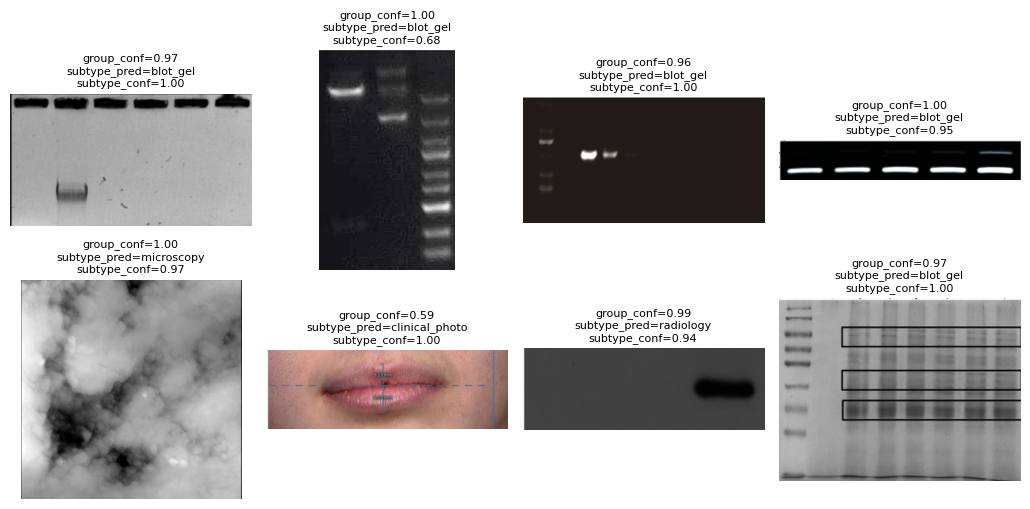


=== group_pred: non_imaging | count=17 | showing=8 ===


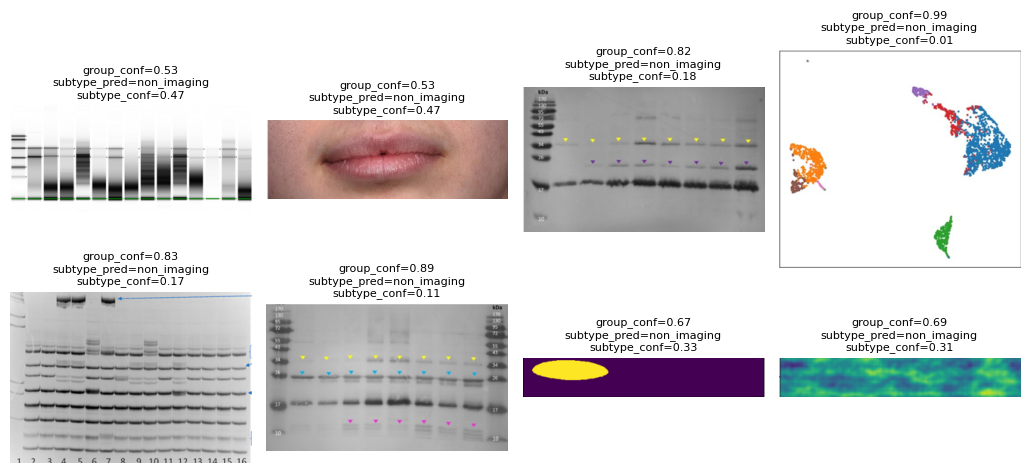


=== subtype_pred: assay_plate | count=2 | showing=2 ===


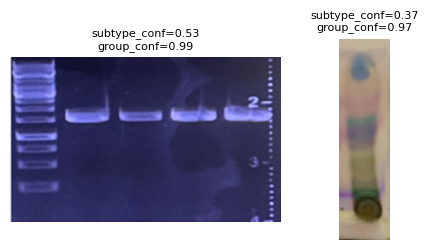


=== subtype_pred: blot_gel | count=74 | showing=8 ===


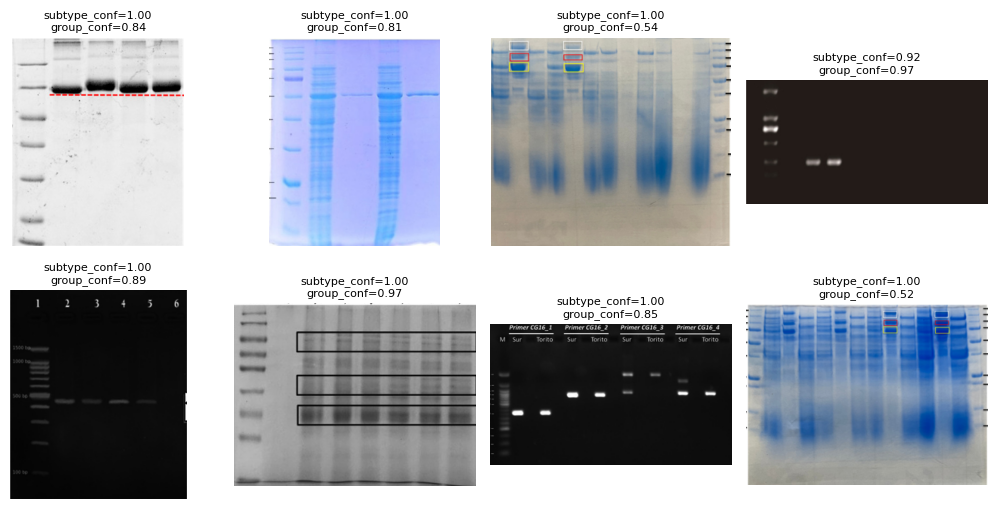


=== subtype_pred: clinical_photo | count=2 | showing=2 ===


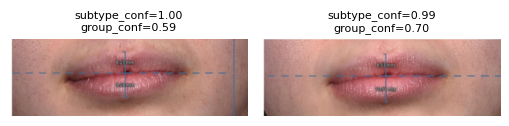


=== subtype_pred: microscopy | count=3 | showing=3 ===


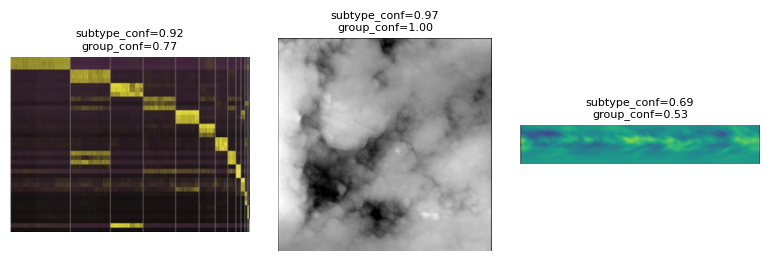


=== subtype_pred: radiology | count=2 | showing=2 ===


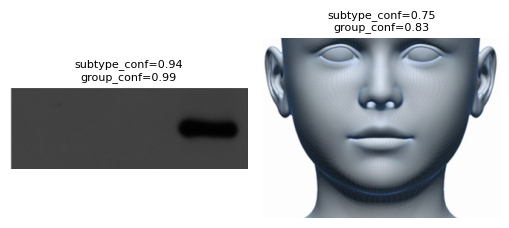

In [67]:
# MAIN: imaging vs non_imaging
show_random_samples_by_category(
    df,
    category_col="group_pred",
    n_per_cat=8,
    seed=None,  # None => random each run
    extra_title_cols=["group_conf", "subtype_pred", "subtype_conf"],
    decimals=2,
    show_filename=False,   # skip filename (set True if you want)
    ncols=4,
    thumb_size=320
)

# SUBTYPES (only imaging)
df_im = df[df["group_pred"] == "imaging"].copy()

show_random_samples_by_category(
    df_im,
    category_col="subtype_pred",
    n_per_cat=8,
    seed=None,  # random each run
    extra_title_cols=["subtype_conf", "group_conf"],
    decimals=2,
    show_filename=False,
    ncols=4,
    thumb_size=320
)